# ¿Qué tan bueno es realmente este detector?

Tenemos la cadena de transformación y las heurísticas. Falta la parte incómoda: medir
qué tan bien funciona, contra qué se compara, y qué pasa río abajo con los números que
alimenta.

**Requisitos:** `numpy`, `scipy`, `matplotlib`. Opcionalmente `wfdb` para la sección final.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})
FS = 500
TINTA, ROJO, VERDE, AZUL, NARANJA = '#333', '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a'

## 1. Cómo se mide un detector

Dos métricas, y la diferencia entre ellas importa:

**Sensibilidad** = VP / (VP + FN). De los latidos que había, ¿cuántos encontré?

**Valor predictivo positivo** = VP / (VP + FP). De los que reporté, ¿cuántos existían?

No son intercambiables y casi nunca se optimizan juntas. Un detector puede tener 100% de
sensibilidad marcando todo como latido, y 100% de VPP marcando un solo latido obvio.

Un detalle de implementación que suele descuidarse: la **tolerancia de emparejamiento**.
Un pico detectado 150 ms fuera de su sitio, ¿cuenta como acierto? Aquí se usan 150 ms, que
es lo habitual en la literatura. Cambiar ese número cambia los resultados.

In [2]:
import numpy as np
from scipy import signal as sg

def paso_banda(x, fs, lo=5.0, hi=15.0, orden=3):
    """Etapa 1: aislar la banda donde domina el QRS."""
    sos = sg.butter(orden,[lo,hi],'bandpass',fs=fs,output='sos')
    return sg.sosfiltfilt(sos,x)

def derivada(x, fs):
    """Etapa 2: filtro diferenciador de 5 puntos del Pan-Tompkins original.

    y[n] = (1/8T)(-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2])
    Resalta pendientes abruptas; aplana ondas P y T, que son lentas.
    """
    h = np.array([-1,-2,0,2,1], dtype=float)*(fs/8.0)
    return np.convolve(x, h[::-1], mode='same')

def cuadrado(x):
    """Etapa 3: no linealidad. Todo positivo y los picos grandes se amplifican."""
    return x**2

def integrar(x, fs, ventana=0.150):
    """Etapa 4: media movil. Convierte cada QRS en una sola joroba."""
    n = max(1,int(round(ventana*fs)))
    return np.convolve(x, np.ones(n)/n, mode='same')

def cadena(x, fs, ventana=0.150, banda=(5.0,15.0)):
    b = paso_banda(x,fs,*banda)
    d = derivada(b,fs)
    c = cuadrado(d)
    i = integrar(c,fs,ventana)
    return b,d,c,i

In [3]:
import numpy as np
from scipy import signal as sg


def detectar(x, fs, umbral_adaptativo=True, refractario=True, regla_360=True,
             search_back=True, ventana=0.150, k_inicial=0.25):
    """Pan-Tompkins con sus heuristicas conmutables, para ablacion.

    Devuelve las posiciones (en segundos) de los picos R detectados.
    """
    b,d,c,integrada = cadena(x, fs, ventana=ventana)
    n = len(integrada)

    # candidatos: maximos locales de la senal integrada.
    # OJO: el parametro distance de find_peaks YA es un periodo refractario
    # implicito. Para que la ablacion sea honesta, se desactiva junto con el.
    dist = int(0.10*fs) if refractario else 1
    cand,_ = sg.find_peaks(integrada, distance=dist)
    if len(cand)==0: return np.array([]), {}

    # inicializacion sobre los primeros 2 s (fase de aprendizaje del original)
    ini = integrada[:int(2*fs)]
    SPKI = 0.25*ini.max() if len(ini) else integrada.max()*0.25
    NPKI = 0.5*ini.mean() if len(ini) else 0.0
    UMBRAL = NPKI + 0.25*(SPKI-NPKI)
    if not umbral_adaptativo:
        UMBRAL = k_inicial*np.percentile(integrada,99)

    picos=[]; rr=[]; rr_medio=None; ultimo=-np.inf
    # La "pendiente maxima" del original se mide sobre la senal DERIVADA,
    # no sobre la integrada: en el pico de la integrada la pendiente es cero.
    absd = np.abs(d)
    w_p = int(0.05*fs)
    def pend_max(q):
        a,b_ = max(0,q-w_p), min(n,q+w_p)
        return absd[a:b_].max()
    aceptados_idx=[]

    i=0
    while i < len(cand):
        p = cand[i]; tp = p/fs
        if integrada[p] > UMBRAL:
            # --- periodo refractario ---
            if refractario and (tp-ultimo) < 0.200:
                i+=1; continue
            # --- regla de los 360 ms: descartar onda T ---
            if regla_360 and picos and 0.200 <= (tp-ultimo) < 0.360:
                if pend_max(p) < 0.5*pend_max(int(ultimo*fs)):
                    if umbral_adaptativo:            # se trata como ruido
                        NPKI = 0.125*integrada[p] + 0.875*NPKI
                        UMBRAL = NPKI + 0.25*(SPKI-NPKI)
                    i+=1; continue
            picos.append(tp); aceptados_idx.append(p)
            if ultimo>-np.inf: rr.append(tp-ultimo)
            ultimo=tp
            if umbral_adaptativo:
                SPKI = 0.125*integrada[p] + 0.875*SPKI
                UMBRAL = NPKI + 0.25*(SPKI-NPKI)
        else:
            if umbral_adaptativo:
                NPKI = 0.125*integrada[p] + 0.875*NPKI
                UMBRAL = NPKI + 0.25*(SPKI-NPKI)

        # --- search-back ---
        if search_back and len(rr)>=3:
            rr_medio=np.mean(rr[-8:])
            if i+1<len(cand):
                sig_t = cand[i+1]/fs
                if (sig_t-ultimo) > 1.66*rr_medio:
                    # buscar el mayor candidato en el hueco con umbral a la mitad
                    hueco=[q for q in cand if ultimo+0.200 < q/fs < sig_t]
                    if hueco:
                        mejor=max(hueco,key=lambda q: integrada[q])
                        if integrada[mejor] > 0.5*UMBRAL:
                            tm=mejor/fs
                            picos.append(tm); aceptados_idx.append(mejor)
                            rr.append(tm-ultimo); ultimo=tm
                            if umbral_adaptativo:
                                SPKI=0.25*integrada[mejor]+0.75*SPKI
                                UMBRAL=NPKI+0.25*(SPKI-NPKI)
        i+=1

    picos=np.array(sorted(picos))
    return picos, dict(integrada=integrada, umbral_final=UMBRAL)

def evaluar(det, verd, tol=0.15):
    """Sensibilidad y valor predictivo positivo."""
    if len(det)==0: return 0.0,0.0,0,len(verd),0
    usados=set(); VP=0
    for tv in verd:
        j=int(np.argmin(np.abs(det-tv)))
        if abs(det[j]-tv)<tol and j not in usados:
            usados.add(j); VP+=1
    FN=len(verd)-VP; FP=len(det)-VP
    Se = 100*VP/max(VP+FN,1); VPP = 100*VP/max(VP+FP,1)
    return Se,VPP,VP,FN,FP

In [4]:
import numpy as np
from scipy import signal as sg
FS=500

def ecg(dur=180.0, hr=62.0, amp_r=1.30, amp_t=0.30, sigma_t=0.045,
        modulacion=0.0, desvanecer=False, semilla=7, fs=FS):
    """ECG configurable. modulacion: variacion de amplitud del QRS (0-1).
    desvanecer: la amplitud cae linealmente a la mitad en la segunda mitad."""
    rng=np.random.default_rng(semilla)
    n=int(fs*dur); t=np.arange(n)/fs; x=np.zeros(n); tr=0.5; p=[]
    while tr<dur-0.6:
        p.append(tr)
        ka = 1 + modulacion*np.sin(2*np.pi*0.20*tr)
        if desvanecer: ka *= (1.0 - 0.55*max(0.0,(tr-dur/2))/(dur/2))
        for c,a,s in [(-0.200,0.15,0.025),(-0.035,-0.10,0.008),(0.0,1.10,0.010),
                      (0.035,-0.25,0.010),(0.280,amp_t,sigma_t)]:
            x += a*ka*np.exp(-0.5*((t-(tr+c))/s)**2)
        tr += max(0.35, rng.normal(60/hr,0.045))
    return t, x*(amp_r/1.10), np.array(p)

def ruido(t, fs=FS, emg_amp=0.03, semilla=11):
    rng=np.random.default_rng(semilla)
    dv=0.35*np.sin(2*np.pi*0.28*t)+0.18*np.sin(2*np.pi*0.09*t+1.1)
    rd=0.12*np.sin(2*np.pi*60*t)+0.034*np.sin(2*np.pi*120*t+0.7)
    sos=sg.butter(4,[20,150],'bandpass',fs=fs,output='sos')
    return dv+rd+emg_amp*sg.sosfilt(sos,rng.standard_normal(len(t)))

ESCENARIOS = {
 'normal':            dict(),
 'T picuda':          dict(amp_t=0.70, sigma_t=0.028),
 'amplitud variable': dict(modulacion=0.55),
 'señal que decae':   dict(desvanecer=True),
 'taquicardia':       dict(hr=145),
}

In [5]:
import numpy as np
from scipy import signal as sg


def ingenuo(x, fs, k=0.6):
    """Detector ingenuo: umbral fijo sobre la senal cruda."""
    p,_ = sg.find_peaks(x, height=k*np.max(x), distance=int(0.25*fs))
    return p/fs

def umbral_fijo(x, fs, k=0.25, ventana=0.150):
    """Cadena de Pan-Tompkins + umbral fijo, sin heuristicas."""
    _,_,_,i = cadena(x, fs, ventana=ventana)
    p,_ = sg.find_peaks(i, height=k*np.percentile(i,99), distance=int(0.25*fs))
    return p/fs

## 2. Contra qué se compara

Dos rivales deliberadamente más simples:

- **Umbral sobre la señal cruda**: lo primero que a cualquiera se le ocurre.
- **Cadena + umbral fijo**: las cuatro transformaciones sin ninguna heurística.

Y el estrés: **artefacto de movimiento**, ruido de banda 5–25 Hz en ráfagas. Es el ruido
que importa, porque cae dentro de la banda del detector. El ruido EMG de 20–150 Hz que
usamos en artículos anteriores lo elimina el paso-banda casi por completo: parece severo
y no estresa nada.

In [6]:
def artefacto(t, fs, escala, semilla=11):
    """Artefacto de movimiento: ruido dentro de la banda del detector, en ráfagas."""
    rng = np.random.default_rng(semilla)
    deriva = 0.35*np.sin(2*np.pi*0.28*t) + 0.18*np.sin(2*np.pi*0.09*t+1.1)
    red = 0.12*np.sin(2*np.pi*60*t)
    sos = sg.butter(4, [5, 25], 'bandpass', fs=fs, output='sos')
    mov = sg.sosfilt(sos, rng.standard_normal(len(t)))
    mov /= np.sqrt((mov**2).mean())
    env = np.ones_like(t)
    for c in np.arange(6, t[-1], 11.0):
        env += 2.5*np.exp(-0.5*((t-c)/1.2)**2)
    return deriva + red + escala*mov*env


t, limpio, pv = ecg(dur=180.0, modulacion=0.35)
potencia = (limpio**2).mean()

print(f'{"SNR(dB)":>8} | {"Pan-Tompkins":>21} | {"umbral fijo":>21} | {"señal cruda":>21}')
print(f'{"":>8} | {"Se":>9} {"VPP":>10} | {"Se":>9} {"VPP":>10} | {"Se":>9} {"VPP":>10}')
print('-'*82)
filas = []
for escala in (0.0, 0.02, 0.04, 0.07, 0.10, 0.15, 0.22, 0.32):
    n = artefacto(t, FS, escala); x = limpio + n
    snr = 10*np.log10(potencia/(n**2).mean())
    txt = f'{snr:>8.1f} |'; fila = [snr]
    for f in (lambda: detectar(x, FS)[0], lambda: umbral_fijo(x, FS),
              lambda: ingenuo(x, FS)):
        Se, VPP, _, _, _ = evaluar(f(), pv)
        txt += f'{Se:>8.1f}% {VPP:>9.1f}% |'; fila += [Se, VPP]
    print(txt); filas.append(fila)
filas = np.array(filas)

 SNR(dB) |          Pan-Tompkins |           umbral fijo |           señal cruda
         |        Se        VPP |        Se        VPP |        Se        VPP
----------------------------------------------------------------------------------
    -2.6 |   100.0%     100.0% |   100.0%     100.0% |    48.1%     100.0% |
    -2.7 |   100.0%     100.0% |    96.8%     100.0% |    53.5%     100.0% |
    -2.9 |    99.5%      98.4% |    92.0%     100.0% |    53.5%     100.0% |
    -3.4 |    97.9%      78.5% |    88.8%      91.2% |    52.4%     100.0% |


    -4.1 |    97.9%      51.3% |    82.4%      76.6% |    47.1%      98.9% |
    -5.5 |    98.4%      38.9% |    72.2%      65.9% |    39.0%      92.4% |
    -7.4 |    95.7%      35.8% |    43.3%      51.9% |    37.4%      71.4% |


    -9.9 |    96.3%      34.4% |    26.7%      38.5% |    16.0%      55.6% |


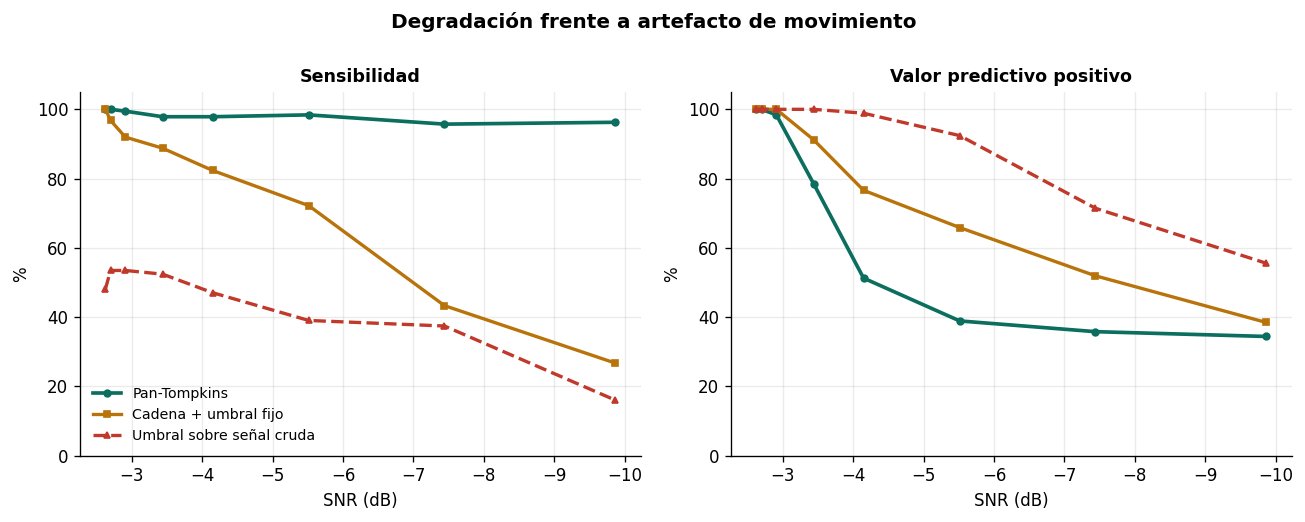

In [7]:
snr = filas[:,0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, off, tit in [(a1, 1, 'Sensibilidad'), (a2, 2, 'Valor predictivo positivo')]:
    ax.plot(snr, filas[:,off],   color=VERDE,   lw=2.2, marker='o', ms=4, label='Pan-Tompkins')
    ax.plot(snr, filas[:,off+2], color=NARANJA, lw=2.0, marker='s', ms=4, label='Cadena + umbral fijo')
    ax.plot(snr, filas[:,off+4], color=ROJO,    lw=2.0, marker='^', ms=4, ls='--',
            label='Umbral sobre señal cruda')
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('%'); ax.set_ylim(0, 105)
    ax.set_title(tit, fontweight='bold', fontsize=10.5); ax.invert_xaxis()
a1.legend(loc='lower left', frameon=False, fontsize=8.5)
fig.suptitle('Degradación frente a artefacto de movimiento', fontweight='bold', y=1.0)
fig.tight_layout()
plt.show()

## 3. Pan-Tompkins tiene un sesgo, y es deliberado

Los dos paneles cuentan historias distintas.

En **sensibilidad**, Pan-Tompkins se mantiene por encima del 95% incluso a −10 dB, mientras
el umbral fijo cae al 27% y el detector ingenuo al 16%.

En **VPP**, Pan-Tompkins cae al 34%: por cada latido real reporta dos que no existen.

No pierde latidos. Los inventa.

Eso no es un defecto: es el sesgo que el search-back y el umbral adaptativo introducen a
propósito. En un monitor cardiaco, no detectar una asistolia mata a alguien; una alarma de
más molesta a una enfermera. La asimetría está bien elegida para su uso original.

Pero si lo que quieres es calcular variabilidad cardiaca en un estudio, ese mismo sesgo
juega en tu contra. Y aquí es donde el artículo se pone incómodo.

## 4. Lo que un 1% de error le hace a tus métricas

Tomamos la serie de latidos verdadera y le introducimos errores controlados.

In [8]:
def metricas(picos):
    rr = np.diff(picos)*1000
    return dict(BPM=60000/rr.mean(), SDNN=rr.std(ddof=1),
                RMSSD=np.sqrt(np.mean(np.diff(rr)**2)))


def corromper(p, tasa_fp=0.0, tasa_fn=0.0, semilla=3):
    """Introduce falsos positivos (latidos inventados entre dos reales)
    o falsos negativos (latidos perdidos)."""
    r = np.random.default_rng(semilla); q = list(p)
    if tasa_fn > 0:
        n = int(round(tasa_fn*len(p)))
        quitar = set(r.choice(np.arange(1, len(p)-1), size=n, replace=False))
        q = [v for k, v in enumerate(q) if k not in quitar]
    if tasa_fp > 0:
        n = int(round(tasa_fp*len(p)))
        idx = r.choice(np.arange(1, len(q)-1), size=n, replace=False)
        q = sorted(q + [(q[k]+q[k+1])/2 for k in idx])
    return np.array(q)


t, limpio, pv = ecg(dur=300.0)
base = metricas(pv)
print(f'VERDAD: {base["BPM"]:.2f} lpm | SDNN {base["SDNN"]:.2f} ms | '
      f'RMSSD {base["RMSSD"]:.2f} ms\n')
print(f'{"error introducido":>22} | {"BPM":>17} | {"SDNN":>19} | {"RMSSD":>19}')
print('-'*84)
for etq, kw in [('0.5% falsos positivos', dict(tasa_fp=0.005)),
                ('1% falsos positivos',   dict(tasa_fp=0.01)),
                ('2% falsos positivos',   dict(tasa_fp=0.02)),
                ('0.5% latidos perdidos', dict(tasa_fn=0.005)),
                ('1% latidos perdidos',   dict(tasa_fn=0.01)),
                ('2% latidos perdidos',   dict(tasa_fn=0.02))]:
    m = metricas(corromper(pv, **kw))
    print(f'{etq:>22} | {m["BPM"]:>7.2f} ({100*(m["BPM"]/base["BPM"]-1):+5.1f}%) | '
          f'{m["SDNN"]:>7.2f} ({100*(m["SDNN"]/base["SDNN"]-1):+6.1f}%) | '
          f'{m["RMSSD"]:>7.2f} ({100*(m["RMSSD"]/base["RMSSD"]-1):+6.1f}%)')

VERDAD: 62.36 lpm | SDNN 41.54 ms | RMSSD 58.68 ms

     error introducido |               BPM |                SDNN |               RMSSD
------------------------------------------------------------------------------------
 0.5% falsos positivos |   62.76 ( +0.6%) |   71.51 ( +72.2%) |   78.80 ( +34.3%)
   1% falsos positivos |   62.96 ( +1.0%) |   80.79 ( +94.5%) |   88.82 ( +51.4%)
   2% falsos positivos |   63.56 ( +1.9%) |  102.26 (+146.2%) |   95.33 ( +62.4%)
 0.5% latidos perdidos |   61.95 ( -0.6%) |   74.98 ( +80.5%) |  107.92 ( +83.9%)
   1% latidos perdidos |   61.75 ( -1.0%) |   94.14 (+126.6%) |  134.21 (+128.7%)
   2% latidos perdidos |   61.15 ( -1.9%) |  173.45 (+317.6%) |  246.00 (+319.2%)


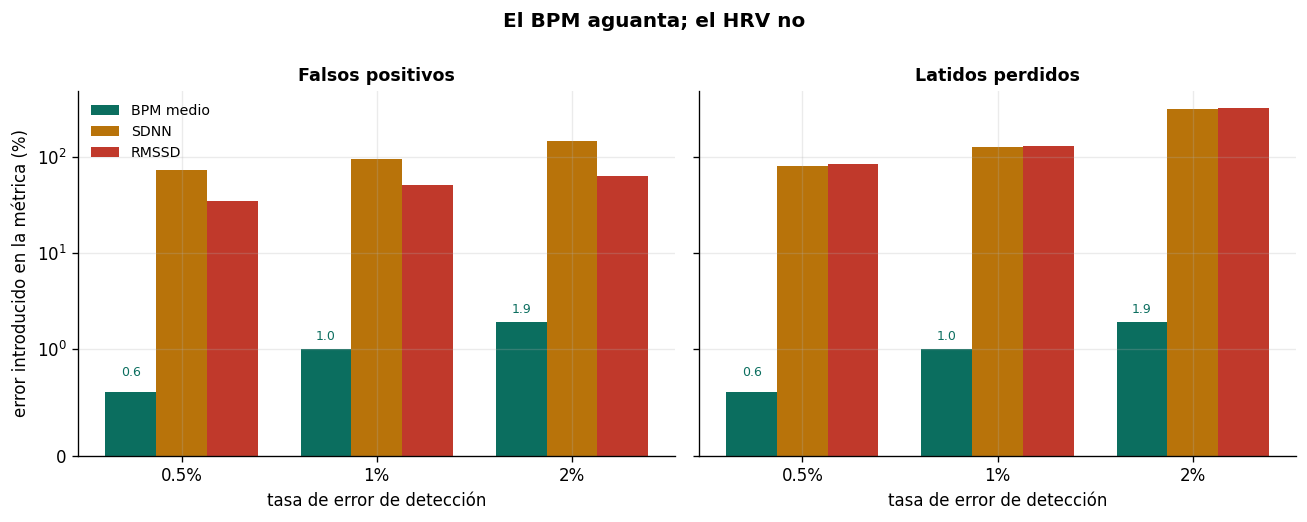

In [9]:
etq = ['0.5%', '1%', '2%']
fp = ([0.6,1.0,1.9], [72.2,94.5,146.2], [34.3,51.4,62.4])
fn = ([0.6,1.0,1.9], [80.5,126.6,317.6], [83.9,128.7,319.2])
xx = np.arange(3); w = 0.26

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (b, s_, r), tit in [(a1, fp, 'Falsos positivos'), (a2, fn, 'Latidos perdidos')]:
    ax.bar(xx-w, b,  w, color=VERDE,   label='BPM medio')
    ax.bar(xx,   s_, w, color=NARANJA, label='SDNN')
    ax.bar(xx+w, r,  w, color=ROJO,    label='RMSSD')
    ax.set_xticks(xx); ax.set_xticklabels(etq)
    ax.set_xlabel('tasa de error de detección')
    ax.set_title(tit, fontweight='bold', fontsize=10.5)
    ax.set_yscale('symlog', linthresh=1)
    for i, v in enumerate(b):
        ax.text(i-w, v*1.25, f'{v:.1f}', ha='center', fontsize=7.5, color=VERDE)
a1.set_ylabel('error introducido en la métrica (%)')
a1.legend(loc='upper left', frameon=False, fontsize=8.5)
fig.suptitle('El BPM aguanta; el HRV no', fontweight='bold', y=1.0)
fig.tight_layout()
plt.show()

Un 1% de latidos perdidos mueve el **BPM medio un 1%** y el **RMSSD un 128%**.

La razón es estructural. El BPM medio es un promedio sobre cientos de intervalos: un error
aislado se diluye. El RMSSD es la raíz de la media de las diferencias **al cuadrado** entre
intervalos consecutivos, así que un solo intervalo del doble de largo entra elevado al
cuadrado y domina la suma.

Dicho de otro modo: **un detector con 99% de sensibilidad es excelente para reportar
frecuencia cardiaca e inservible para calcular HRV sin corrección posterior.**

Esto cierra un círculo con el artículo sobre retardo de grupo. Allí vimos que la elección
del filtro cambia el SDNN un 0.4%. Aquí, un 1% de error de detección lo cambia un 127%.
**La fuente dominante de error en HRV no es el filtrado: es la detección.**

## 5. Ni siquiera la detección perfecta basta

Un último giro. Generamos un ECG con extrasístoles ventriculares —QRS ancho, prematuro,
seguido de pausa compensadora— y verificamos primero que el detector las encuentre.

In [10]:
import numpy as np
from scipy import signal as sg

FS=500

def ecg_extra(dur=180.0, hr=62.0, prop_extra=0.10, fs=FS, semilla=5):
    """ECG con extrasistoles ventriculares: QRS ancho, prematuro y con pausa
    compensadora. Es el caso donde la regla de 360 ms puede equivocarse."""
    rng=np.random.default_rng(semilla)
    n=int(fs*dur); t=np.arange(n)/fs; x=np.zeros(n); tr=0.5; p=[]; tipos=[]
    normal=[(-0.200,0.15,0.025),(-0.035,-0.10,0.008),(0.0,1.10,0.010),
            (0.035,-0.25,0.010),(0.280,0.30,0.045)]
    # extrasistole: sin P, QRS ancho y de polaridad distinta, T opuesta
    extra=[(0.0,-0.95,0.028),(0.045,0.55,0.030),(0.300,-0.35,0.055)]
    rr_med=60/hr
    while tr<dur-0.8:
        es = rng.random()<prop_extra and len(p)>2
        p.append(tr); tipos.append('V' if es else 'N')
        for c,a,s in (extra if es else normal):
            x+=a*np.exp(-0.5*((t-(tr+c))/s)**2)
        if es:
            tr += 1.55*rr_med          # pausa compensadora
        else:
            tr += max(0.35, rng.normal(rr_med,0.045))
            if rng.random()<prop_extra: tr -= 0.28*rr_med   # prematuridad
    return t, x*(1.30/1.10), np.array(p), np.array(tipos)

def ruido(t, fs=FS, semilla=11):
    rng=np.random.default_rng(semilla)
    sos=sg.butter(4,[20,150],'bandpass',fs=fs,output='sos')
    return (0.35*np.sin(2*np.pi*0.28*t)+0.12*np.sin(2*np.pi*60*t)
            +0.03*sg.sosfilt(sos,rng.standard_normal(len(t))))

t,limpio,pv,tipos = ecg_extra()
x = limpio + ruido(t)
nV=int(np.sum(tipos=='V'))
print(f'{len(pv)} latidos, de los cuales {nV} extrasistoles ventriculares\n')
print(f'{"configuración":>26} | {"Se global":>10} | {"Se en extrasístoles":>20} | {"VPP":>7}')
print('-'*72)
for nom,cfg in [('completo',{}),('sin regla de 360 ms',dict(regla_360=False)),
                ('sin search-back',dict(search_back=False))]:
    d,_=detectar(x,FS,**cfg)
    Se,VPP,_,_,_=evaluar(d,pv)
    ok=sum(1 for tv in pv[tipos=='V'] if len(d) and np.min(np.abs(d-tv))<0.15)
    print(f'{nom:>26} | {Se:>9.1f}% | {100*ok/max(nV,1):>19.1f}% | {VPP:>6.1f}%')

177 latidos, de los cuales 21 extrasistoles ventriculares

             configuración |  Se global |  Se en extrasístoles |     VPP
------------------------------------------------------------------------
                  completo |     100.0% |               100.0% |  100.0%
       sin regla de 360 ms |     100.0% |               100.0% |  100.0%
           sin search-back |     100.0% |               100.0% |  100.0%


In [11]:
t, limpio, pv, tipos = ecg_extra()
x = limpio + ruido(t)
nV = int(np.sum(tipos == 'V'))
print(f'{len(pv)} latidos, {nV} extrasístoles ventriculares\n')
print(f'{"configuración":>26} | {"Se global":>10} | {"Se en extrasístoles":>20} | {"VPP":>7}')
print('-'*72)
for nombre, cfg in [('completo', {}), ('sin regla de 360 ms', dict(regla_360=False))]:
    d, _ = detectar(x, FS, **cfg)
    Se, VPP, _, _, _ = evaluar(d, pv)
    ok = sum(1 for tv in pv[tipos == 'V'] if len(d) and np.min(np.abs(d-tv)) < 0.15)
    print(f'{nombre:>26} | {Se:>9.1f}% | {100*ok/max(nV,1):>19.1f}% | {VPP:>6.1f}%')

177 latidos, 21 extrasístoles ventriculares

             configuración |  Se global |  Se en extrasístoles |     VPP
------------------------------------------------------------------------
                  completo |     100.0% |               100.0% |  100.0%
       sin regla de 360 ms |     100.0% |               100.0% |  100.0%


Las detecta todas. El temor de que la regla de 360 ms descarte extrasístoles no se
materializa: aunque el QRS ectópico es ancho, su pendiente es comparable a la de un latido
normal, así que supera el umbral del 50%.

Detección perfecta, entonces. Veamos el HRV.

In [12]:
def m3(p):
    rr = np.diff(p)*1000
    return 60000/rr.mean(), rr.std(ddof=1), np.sqrt(np.mean(np.diff(rr)**2))


bruto = m3(pv)

# Corrección estándar: excluir los intervalos que tocan un latido ectópico
rr = np.diff(pv)*1000
malo = np.zeros(len(rr), bool)
for k, tp in enumerate(tipos):
    if tp == 'V':
        if k > 0: malo[k-1] = True
        if k < len(rr): malo[k] = True
rr_limpio = rr[~malo]
corregido = (60000/rr_limpio.mean(), rr_limpio.std(ddof=1),
             np.sqrt(np.mean(np.diff(rr_limpio)**2)))

print('Detección 100% correcta en ambos casos.\n')
print(f'{"":>32} {"BPM":>8} {"SDNN":>9} {"RMSSD":>9}')
print('-'*61)
print(f'{"con extrasístoles incluidas":>32} {bruto[0]:>8.1f} {bruto[1]:>9.1f} {bruto[2]:>9.1f}')
print(f'{"excluyendo latidos ectópicos":>32} {corregido[0]:>8.1f} {corregido[1]:>9.1f} '
      f'{corregido[2]:>9.1f}')
print(f'{"diferencia":>32} {100*(bruto[0]/corregido[0]-1):>7.1f}% '
      f'{100*(bruto[1]/corregido[1]-1):>8.1f}% {100*(bruto[2]/corregido[2]-1):>8.1f}%')

Detección 100% correcta en ambos casos.

                                      BPM      SDNN     RMSSD
-------------------------------------------------------------
     con extrasístoles incluidas     59.3     197.9     271.8
    excluyendo latidos ectópicos     63.2      87.0     119.0
                      diferencia    -6.2%    127.5%    128.4%


Con detección perfecta, incluir las extrasístoles infla el RMSSD un 128%.

El latido prematuro produce un intervalo corto y la pausa compensadora uno largo. Ninguno
refleja modulación autonómica —que es lo que el HRV pretende medir— pero ambos entran en
la cuenta.

**Detectar bien los latidos no es suficiente. Hay que decidir cuáles cuentan.** Por eso los
protocolos de HRV exigen excluir latidos ectópicos e interpolar, y por eso las guías
recomiendan registros con menos del 5% de latidos anómalos.

## 6. Lo que falta: evaluar contra datos reales

Todo lo anterior está medido sobre señal sintética. Sirve para entender mecanismos y para
comparar configuraciones en igualdad de condiciones, pero **no dice qué tan bueno es este
detector sobre pacientes de verdad**.

Para eso hace falta una base anotada por cardiólogos. El módulo `mitbih.py` del repositorio
hace exactamente eso contra MIT-BIH Arrhythmia; no se ejecuta aquí porque requiere
descargar los registros.

```python
pip install wfdb
python mitbih.py
```

Como referencia: el artículo original reporta 99.3% de sensibilidad sobre esa base. Si tu
implementación se queda muy por debajo, el problema está en tu código, no en el algoritmo.

Al comparar, cuidado con dos cosas. **La tolerancia de emparejamiento** cambia los números,
y no todos los trabajos usan la misma. Y **las anotaciones incluyen símbolos que no son
latidos** —cambios de ritmo, marcas de ruido— que hay que filtrar antes de contar.

## Dónde falla esto

**La señal es sintética**, y eso limita todas las cifras absolutas de este notebook. Las
comparaciones relativas entre detectores y configuraciones son más confiables que los
valores en sí.

**El artefacto de movimiento está modelado como ruido de banda**, y el real es más
estructurado: escalones por despegue de electrodo, transitorios con forma parecida a un
QRS. Esos son peores.

**Solo hay un tipo de arritmia.** La fibrilación auricular, con su irregularidad
sostenida, rompe supuestos distintos: el search-back espera un RR medio estable, y en FA
no lo hay.

**No se midió el consumo ni la latencia**, que eran restricciones centrales del diseño
original. Esta implementación es diferida y vectorizada; el algoritmo real corre muestra a
muestra.

## Referencias

- Pan J., Tompkins W. *A Real-Time QRS Detection Algorithm.* IEEE Trans. Biomed. Eng., 1985.
- Task Force of the ESC and NASPE. *Heart rate variability: standards of measurement,
  physiological interpretation, and clinical use.* Circulation, 1996.
- Moody G., Mark R. *The impact of the MIT-BIH Arrhythmia Database.* IEEE Eng. Med. Biol., 2001.